<a href="https://colab.research.google.com/github/TingyuZhao19/MSSP6070/blob/main/WeeklyModules/Week07/PARTICIPATION_ACTIVITY_Week_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path
import pandas as pd

path = Path("/content/drive/MyDrive/MSSP607/Modules/Week07/InternetSales.csv")
df = pd.read_csv(path, encoding='latin-1')
display(df.head())

/tmp/ipython-input-1835149885.py:5: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, encoding='latin-1')


,ID,CustomerKey,GeographyKey,City,CountryRegionCode,EnglishCountryRegionName,CustomerAlternateKey,Title,FirstName,MiddleName,...,ProductStandardCost,TotalProductCost,SalesAmount,TaxAmt,Freight,CarrierTrackingNumber,CustomerPONumber,OrderDate,DueDate,ShipDate
0,0,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1912.1544,1912.1544,3399.99,271.9992,84.9998,NaN,NaN,1/19/2011,1/31/2011,1/26/2011
1,1,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1265.6195,1265.6195,2319.99,185.5992,57.9998,NaN,NaN,1/18/2013,1/30/2013,1/25/2013
2,2,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,8.2205,8.2205,21.98,1.7584,0.5495,NaN,NaN,1/18/2013,1/30/2013,1/25/2013
3,3,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1481.9379,1481.9379,2384.07,190.7256,59.6018,NaN,NaN,5/3/2013,5/15/2013,5/10/2013
4,4,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,10.8423,10.8423,28.99,2.3192,0.7248,NaN,NaN,5/3/2013,5/15/2013,5/10/2013


# Task
1. Use Google Colabs and Python to create a bar chart of yearly sales from the Internet Sales Data Set Download Internet Sales Data Set.

2. Save the active figure to a file in PDF format.

## Convert 'orderdate' to datetime

### Subtask:
Convert the 'OrderDate' column to datetime objects.


**Reasoning**:
Convert the 'OrderDate' column to datetime objects to prepare for time-based analysis.



In [ ]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60398 entries, 0 to 60397
Data columns (total 60 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   ID                        60398 non-null  int64         
 1   CustomerKey               60398 non-null  int64         
 2   GeographyKey              60398 non-null  int64         
 3   City                      60398 non-null  object        
 4   CountryRegionCode         60398 non-null  object        
 5   EnglishCountryRegionName  60398 non-null  object        
 6   CustomerAlternateKey      60398 non-null  object        
 7   Title                     307 non-null    object        
 8   FirstName                 60398 non-null  object        
 9   MiddleName                34903 non-null  object        
 10  LastName                  60398 non-null  object        
 11  NameStyle                 60398 non-null  bool          
 12  BirthDate         

None

## Extract year

### Subtask:
Extract the year from the 'OrderDate' column and create a new 'Year' column.


**Reasoning**:
Extract the year from the 'OrderDate' column and create a new 'Year' column.



In [ ]:
df['Year'] = df['OrderDate'].dt.year
display(df.head())

,ID,CustomerKey,GeographyKey,City,CountryRegionCode,EnglishCountryRegionName,CustomerAlternateKey,Title,FirstName,MiddleName,...,TotalProductCost,SalesAmount,TaxAmt,Freight,CarrierTrackingNumber,CustomerPONumber,OrderDate,DueDate,ShipDate,Year
0,0,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1912.1544,3399.99,271.9992,84.9998,NaN,NaN,2011-01-19,1/31/2011,1/26/2011,2011
1,1,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1265.6195,2319.99,185.5992,57.9998,NaN,NaN,2013-01-18,1/30/2013,1/25/2013,2013
2,2,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,8.2205,21.98,1.7584,0.5495,NaN,NaN,2013-01-18,1/30/2013,1/25/2013,2013
3,3,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,1481.9379,2384.07,190.7256,59.6018,NaN,NaN,2013-05-03,5/15/2013,5/10/2013,2013
4,4,11000,26,Rockhampton,AU,Australia,AW00011000,NaN,Jon,V,...,10.8423,28.99,2.3192,0.7248,NaN,NaN,2013-05-03,5/15/2013,5/10/2013,2013


## Calculate yearly sales

### Subtask:
Group the data by 'Year' and calculate the sum of 'SalesAmount' for each year.


**Reasoning**:
Group the DataFrame by 'Year' and calculate the sum of 'SalesAmount' for each year.



In [ ]:
yearly_sales = df.groupby('Year')['SalesAmount'].sum()
display(yearly_sales)

,SalesAmount
Year,
2010,4.342104e+04
2011,7.075526e+06
2012,5.842485e+06
2013,1.635155e+07
2014,4.569472e+04


## Create bar chart

### Subtask:
Generate a bar chart using the calculated yearly sales and save the file in PDF format in Drive


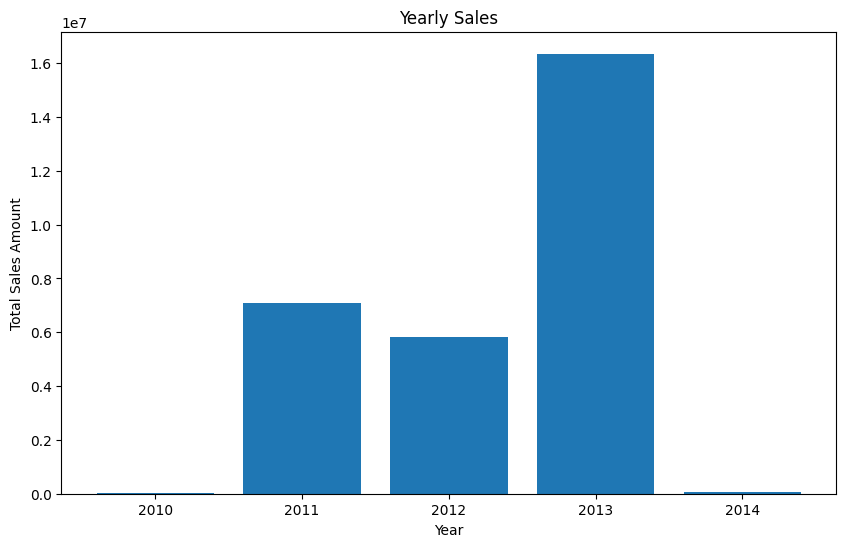

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(yearly_sales.index, yearly_sales.values)
plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales Amount")
plt.xticks(yearly_sales.index)
plt.savefig('/content/drive/MyDrive/MSSP607/Modules/Week07/yearly_sales_bar_chart.pdf', bbox_inches='tight')
plt.show()